# Bangladeshi Taka Note Detection using YOLO - Fine-tuning
### Module 16 Assignment

---

**Dataset Google Drive Link:** [📁 Click Here to Access Dataset](https://drive.google.com/drive/folders/1bwjuPFqZRpnBX6NnW3FvTb9Mo1v9Pu_-?usp=sharing)

---

In [27]:
!pip install ultralytics
%matplotlib inline

In [28]:
import os
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

#Load dataset

In [29]:
drive.mount('/content/drive')
DRIVE_DATASET_ROOT = "/content/drive/MyDrive/dataset"

DATASET_DIR   = os.path.join(DRIVE_DATASET_ROOT, "bankNote_dataset")
DATA_YAML     = os.path.join(DATASET_DIR, "data.yaml")
TEST_IMAGES_DIR = os.path.join(DATASET_DIR, "test", "images")

# Count images in each split
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_DIR, split, "images")
    if os.path.exists(split_path):
        count = len([f for f in os.listdir(split_path) if f.lower().endswith(IMAGE_EXTS)])
        print(f"  {split:>6} images: {count}")

print(f"\n data.yaml found: {os.path.exists(DATA_YAML)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   train images: 298
     val images: 85
    test images: 43

 data.yaml found: True


#Dataset Structure

Randomly shuffles dataset
Splits:
70% train
20% validation
10% test

```
datasets/bankNote_dataset/
├── train/
│ ├── images/
│ └── labels/
├── test/
│ ├── images/
│ └── labels/
├── val/
│ ├── images/
│ └── labels/
```

In [30]:
test_images = [
    f for f in os.listdir(TEST_IMAGES_DIR)
    if f.lower().endswith(IMAGE_EXTS)
]

if not test_images:
    raise FileNotFoundError("No test images found in test/images directory")

TEST_IMAGE = os.path.join(TEST_IMAGES_DIR, test_images[0])

print(f"Using test image: {TEST_IMAGE}")

Using test image: /content/drive/MyDrive/dataset/bankNote_dataset/test/images/100_0_jpg.rf.d3756f250ca953f774668c6db3485984.jpg


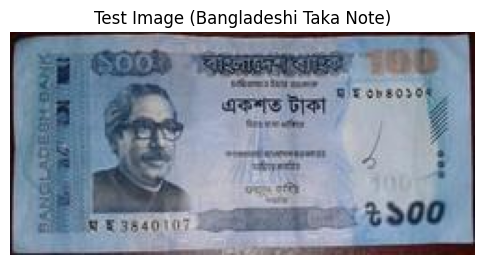

In [31]:
img = Image.open(TEST_IMAGE)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Test Image (Bangladeshi Taka Note)")
plt.show()

#Load Model

In [32]:
pretrained_model = YOLO('/content/drive/MyDrive/dataset/yolo26n.pt')

#Before Fine Tuning

In [33]:
print("Inference using pretrained YOLO26n model (before fine-tuning)...")

pretrained_model.predict(
    source=TEST_IMAGE,
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/dataset/runs/detect",
    name="pretrained_inference"
)

Inference using pretrained YOLO26n model (before fine-tuning)...

image 1/1 /content/drive/MyDrive/dataset/bankNote_dataset/test/images/100_0_jpg.rf.d3756f250ca953f774668c6db3485984.jpg: 320x640 (no detections), 15.8ms
Speed: 2.0ms preprocess, 15.8ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/drive/MyDrive/dataset/runs/detect/pretrained_inference


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

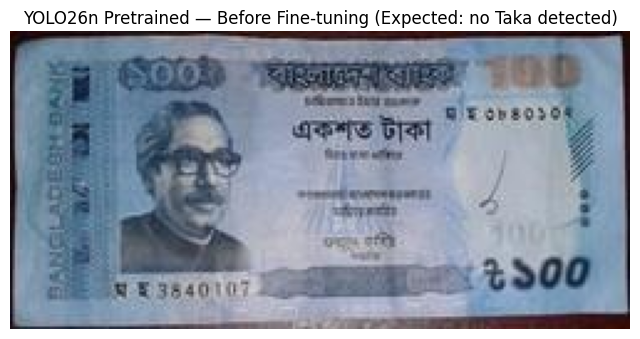

In [34]:
# Display the pretrained inference result

OUTPUT_DIR = os.path.join(DRIVE_DATASET_ROOT,"runs", "detect", "pretrained_inference")

inferred_image_path = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

img = Image.open(inferred_image_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO26n Pretrained — Before Fine-tuning (Expected: no Taka detected)")
plt.show()

#Model Train

In [35]:
data_yaml = os.path.join(
    DRIVE_DATASET_ROOT,
    "bankNote_dataset",
    "data.yaml"
)

# Load pretrained model
model = YOLO("/content/drive/MyDrive/dataset/yolo26n.pt")

model.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/dataset/runs/detect",
    name="bangladeshi_taka_detector",
    device=0 )

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/bankNote_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/dataset/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bangladeshi_taka_detector, nbs=64, nms=False, opset=None, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x799a985e2e40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [36]:
trained_model_path = os.path.join(
    DRIVE_DATASET_ROOT,
    "runs",
    "detect",
    "bangladeshi_taka_detector",
    "weights",
    "best.pt"
)

# Load trained model
trained_model = YOLO(trained_model_path)

print(f"Trained model loaded from: {trained_model_path}")

Trained model loaded from: /content/drive/MyDrive/dataset/runs/detect/bangladeshi_taka_detector/weights/best.pt


#Evaluation

In [37]:
data_yaml = os.path.join(
    DRIVE_DATASET_ROOT,
    "bankNote_dataset",
    "data.yaml"
)

eval_results = trained_model.val(
    data=data_yaml,
    split="test",
    project="/content/drive/MyDrive/dataset/runs/detect",
    imgsz=640,
    conf=0.25
)

print("\n📊 Evaluation Results on Test Set:")
print(f"   mAP@50:    {eval_results.box.map50:.4f}")
print(f"   mAP@50-95: {eval_results.box.map:.4f}")
print(f"   Precision: {eval_results.box.mp:.4f}")
print(f"   Recall:    {eval_results.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,591 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 2.5±1.0 MB/s, size: 5.8 KB)
val: Scanning /content/drive/MyDrive/dataset/bankNote_dataset/test/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 16.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.5it/s 1.2s
                   all         43         43      0.927      0.937      0.946      0.827
                2 taka          3          3          1          1      0.995      0.929
                5 taka          7          7          1      0.714      0.857      0.736
               10 taka          8          8      0.889          1      0.982      0.914
               20 taka          1          1          1          1      0.995      0.995
               50 taka     

The YOLO26n model shows strong performance on the test dataset, achieving an mAP@50 of 0.9456 and mAP@50-95 of 0.8265, which indicates high accuracy in both detecting objects and placing precise bounding boxes. The precision (0.9275) and recall (0.9365) values suggest that the model makes mostly correct predictions while also detecting most of the actual objects. Class-wise results reveal excellent performance for denominations like 2, 20, 50, and 500 taka, while weaker results are observed for 5 taka and 1000 taka, where lower recall and precision indicate missed detections and some misclassifications. These differences are likely due to fewer training samples for certain classes, which limits the model’s ability to generalize effectively.


image 1/1 /content/drive/MyDrive/dataset/bankNote_dataset/test/images/100_0_jpg.rf.d3756f250ca953f774668c6db3485984.jpg: 320x640 2 100 takas, 12.4ms
Speed: 1.8ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/drive/MyDrive/dataset/runs/detect/trained_inference


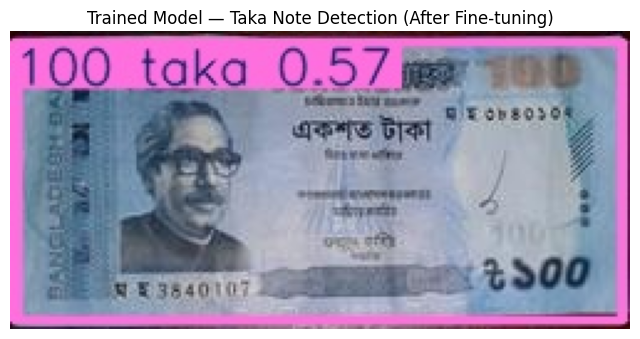

In [38]:
TEST_IMAGES_DIR = os.path.join(DRIVE_DATASET_ROOT,
    "bankNote_dataset", "test", "images")
TEST_IMAGE = os.path.join(TEST_IMAGES_DIR, os.listdir(TEST_IMAGES_DIR)[0])

# Run inference on test image
results = trained_model.predict(
    source=TEST_IMAGE,
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/dataset/runs/detect",
    name="trained_inference"
)

# Display the inference result
OUTPUT_DIR = os.path.join(DRIVE_DATASET_ROOT, "runs", "detect", "trained_inference")
inferred_image_path = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

img = Image.open(inferred_image_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Trained Model — Taka Note Detection (After Fine-tuning)")
plt.show()

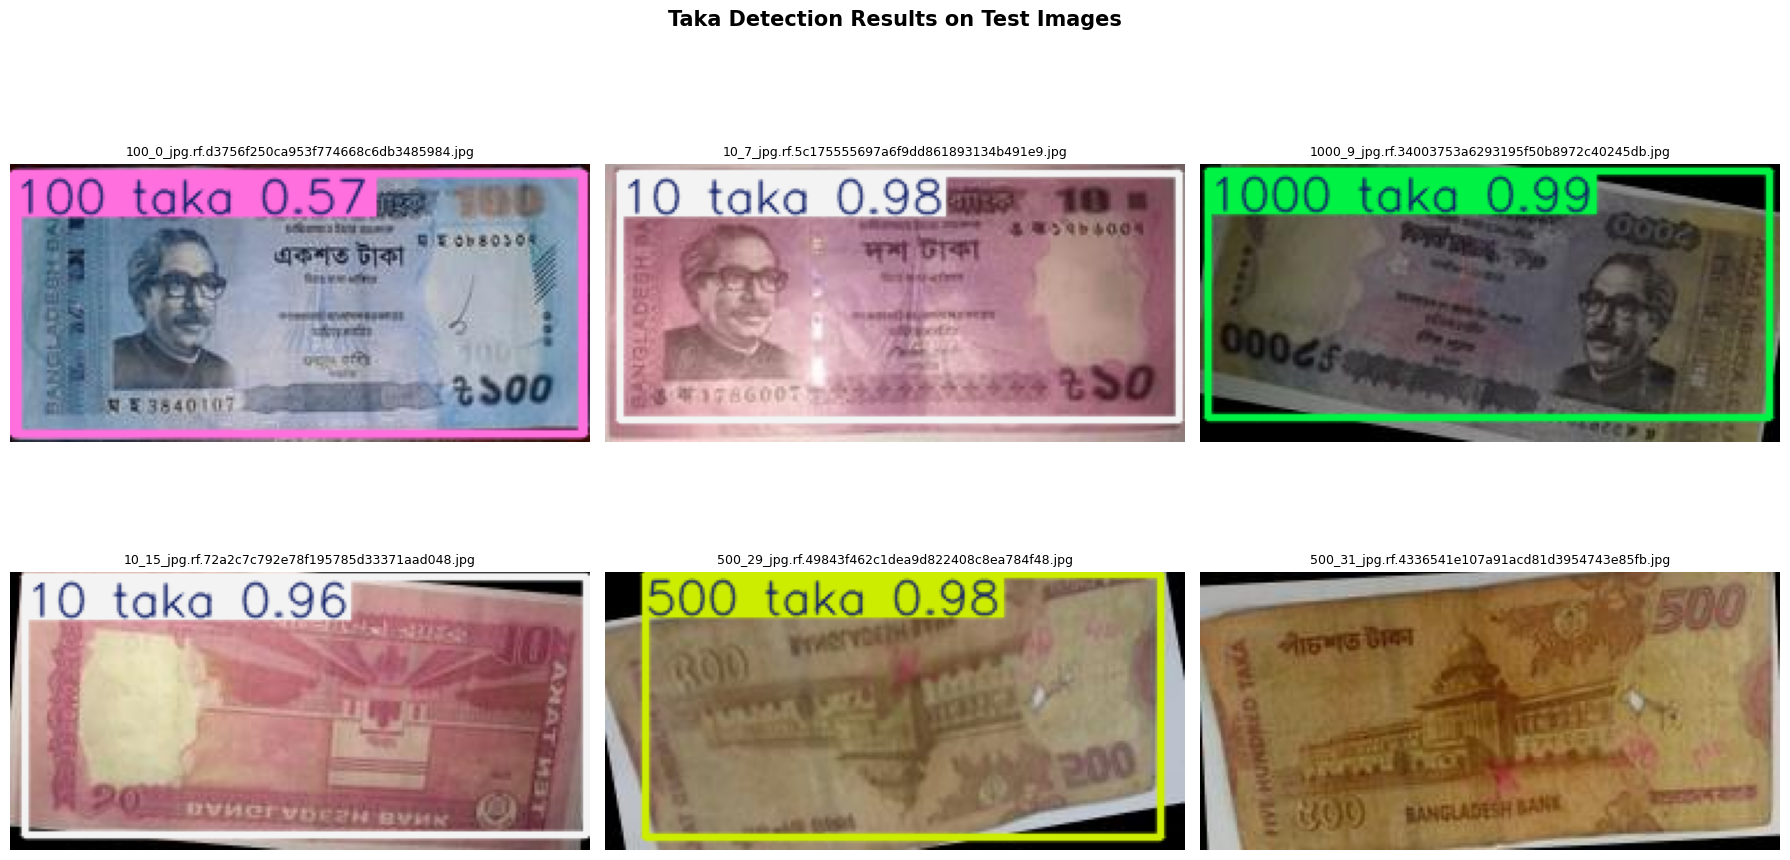

In [39]:
test_image_files = [
    f for f in os.listdir(TEST_IMAGES_DIR)
    if f.lower().endswith(IMAGE_EXTS)
][:8]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taka Detection Results on Test Images", fontsize=15, fontweight="bold")

for ax, fname in zip(axes.flatten(), test_image_files):
    img_path = os.path.join(TEST_IMAGES_DIR, fname)
    result = trained_model.predict(source=img_path, conf=0.25, verbose=False)[0]

    # Plot image from result
    ax.imshow(result.plot()[:, :, ::-1])  # result.plot() returns BGR -> convert to RGB
    ax.axis("off")
    ax.set_title(fname, fontsize=9)

plt.tight_layout()
plt.show()

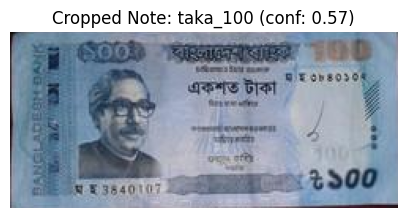

In [40]:
img = Image.open(TEST_IMAGE)

# Get the first detection
if len(results[0].boxes) == 0:
    print("No Taka note detected")
else:
    box = results[0].boxes.xyxy[0]       # x1, y1, x2, y2
    x1, y1, x2, y2 = box.cpu().numpy()  # convert to numpy if on GPU

    cls_id = int(results[0].boxes.cls[0].cpu().numpy())
    conf   = float(results[0].boxes.conf[0].cpu().numpy())

    CLASS_NAMES = [
        "taka_2", "taka_5", "taka_10", "taka_20", "taka_50",
        "taka_100", "taka_200", "taka_500", "taka_1000"
    ]

    # Crop the detected note
    cropped_note = img.crop((int(x1), int(y1), int(x2), int(y2)))

    # Show cropped note
    plt.figure(figsize=(5, 3))
    plt.imshow(cropped_note)
    plt.axis("off")
    plt.title(f"Cropped Note: {CLASS_NAMES[cls_id]} (conf: {conf:.2f})")
    plt.show()

#Train with Coin dataset

In [41]:

EXTENDED_DATASET_DIR = os.path.join(DRIVE_DATASET_ROOT, "coin_dataset")
EXTENDED_DATA_YAML   = os.path.join(DRIVE_DATASET_ROOT, "coin_dataset", "data.yaml")


note_weights = os.path.join(
    DRIVE_DATASET_ROOT,
    "runs", "detect", "bangladeshi_taka_detector", "weights", "best.pt"
)

bonus_model = YOLO(note_weights)

bonus_model.train(
    data=EXTENDED_DATA_YAML,
    epochs=25,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/dataset/runs/detect",
    name="bangladeshi_taka_coins_detector",
    device=0
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/coin_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/dataset/runs/detect/bangladeshi_taka_detector/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bangladeshi_taka_co

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x799b6e7c52b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

#Eavalution

In [42]:
bonus_model_path = os.path.join(
    DRIVE_DATASET_ROOT,
    "runs", "detect", "bangladeshi_taka_coins_detector", "weights", "best.pt"
)

bonus_trained = YOLO(bonus_model_path)

bonus_eval = bonus_trained.val(
    data=EXTENDED_DATA_YAML,
    split="test",
    project="/content/drive/MyDrive/dataset/runs/detect",
    imgsz=640,
    conf=0.25
)

print("\n📊 Bonus Model — Evaluation Results (Notes + Coins):")
print(f"   mAP@50:    {bonus_eval.box.map50:.4f}")
print(f"   mAP@50-95: {bonus_eval.box.map:.4f}")
print(f"   Precision: {bonus_eval.box.mp:.4f}")
print(f"   Recall:    {bonus_eval.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 85.5±50.1 MB/s, size: 239.8 KB)
val: Scanning /content/drive/MyDrive/dataset/coin_dataset/test/labels.cache... 11 images, 0 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 11/11 4.2Mit/s 0.0s
val: /content/drive/MyDrive/dataset/coin_dataset/test/images/bangladeshi coin 2 taka_35.png: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/drive/MyDrive/dataset/coin_dataset/test/images/bangladeshi coin 5 taka_42.jpeg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/drive/MyDrive/dataset/coin_dataset/test/images/bangladeshi coin 5 taka_65.jpeg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
  

#Conclusion

Due to corrupted image or label in coin dataset the mAP declined